## **1 : Configuration et Acquisition des Données**
 Télécharge de manière sécurisée 50 images pour nos 5 catégories (faces, landscapes, logos, cars, animals) depuis Hugging Face.

In [1]:
import cv2
import imagehash
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import random
import os

# Reproductibilité pour l'évaluation scientifique 
random.seed(42)
np.random.seed(42)

# Création du dossier pour les résultats (Point 5 des notes)
dossier_csv = "resultats_csv_semaine2" # On change légèrement le nom pour isoler les nouveaux tests
if not os.path.exists(dossier_csv):
    os.makedirs(dossier_csv)

print(f"Environnement configuré. Dossier '{dossier_csv}' prêt.")

Environnement configuré. Dossier 'resultats_csv_semaine2' prêt.


In [2]:
NB_IMAGES = 50
images_categories = {}

def extraire_images(ds_name, split_name):
    """Téléchargement des images en streaming  RAM."""
    ds = load_dataset(ds_name, split=split_name, streaming=True)
    images = []
    for item in ds:
        # Adaptation intelligente selon la structure du dataset HF
        img_key = 'image' if 'image' in item else ('img' if 'img' in item else None)
        if img_key:
            # On standardise la taille d'entrée à 500x500 pour que les occlusions soient comparables
            images.append(item[img_key].convert('RGB').resize((500, 500)))
        if len(images) == NB_IMAGES:
            break
    return images

def charger_categorie(nom, liste_liens_hf):
    """Teste plusieurs miroirs pour garantir le téléchargement de la catégorie."""
    for lien in liste_liens_hf:
        try:
            images_categories[nom] = extraire_images(lien, "train")
            print(f"[Succès] {nom.capitalize():<10} : {len(images_categories[nom])} images depuis '{lien}'")
            return 
        except Exception:
            continue # Passage au lien suivant si échec
            
    print(f"[ERREUR] Impossible de charger la catégorie {nom}. Tous les miroirs ont échoué.")

print("Fonctions d'acquisition chargées. ")

Fonctions d'acquisition chargées. 


  LANCEMENT DE L'ACQUISITION DES IMAGES


In [3]:
print("Récupération des images en streaming depuis Hugging Face...\n")

charger_categorie("faces", ["nielsr/CelebA-faces"])
charger_categorie("landscapes", ["blanchon/EuroSAT_RGB"])
charger_categorie("logos", ["logo-wizard/modern-logo-dataset"])

# Les voitures ont souvent des liens instables, on maintient ta logique de 3 miroirs
charger_categorie("cars", [
    "tanganke/stanford_cars", 
    "pcuenq/stanford-cars", 
    "evanarlian/imagenet_1k_cars"
])

charger_categorie("animals", ["Bingsu/Cat_and_Dog"])

print(f"\n ACQUISITION TERMINÉE : {len(images_categories)} catégories .")

Récupération des images en streaming depuis Hugging Face...

[Succès] Faces      : 50 images depuis 'nielsr/CelebA-faces'
[Succès] Landscapes : 50 images depuis 'blanchon/EuroSAT_RGB'
[Succès] Logos      : 50 images depuis 'logo-wizard/modern-logo-dataset'
[Succès] Cars       : 50 images depuis 'tanganke/stanford_cars'
[Succès] Animals    : 50 images depuis 'Bingsu/Cat_and_Dog'

 ACQUISITION TERMINÉE : 5 catégories .


## **Visualisation des échantillons**


Visualisation (2 images /catégorie)


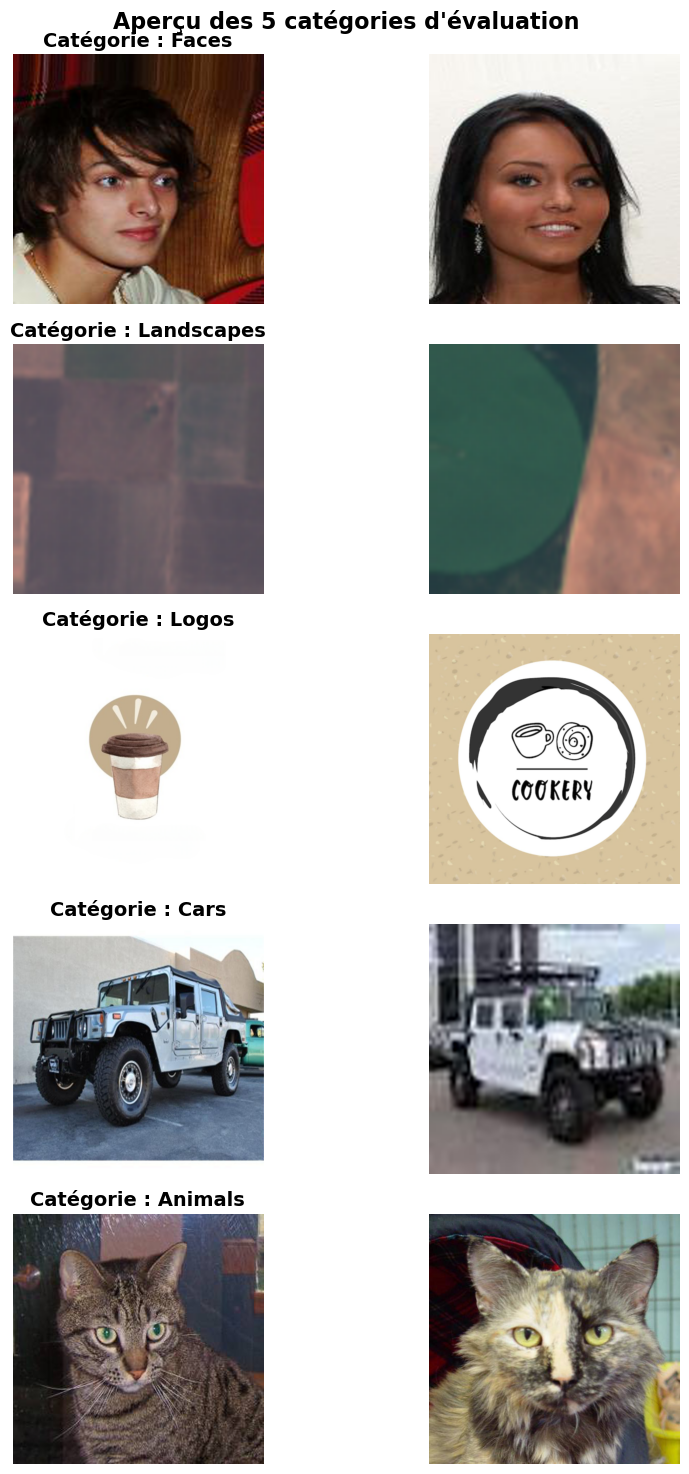

In [4]:
# [TAG: 02_VISUALISATION_DATASET] - Vérification visuelle des catégories

import matplotlib.pyplot as plt

print("Visualisation (2 images /catégorie)")

# 
fig, axes = plt.subplots(5, 2, figsize=(10, 15))
fig.suptitle("Aperçu des 5 catégories d'évaluation", fontsize=16, fontweight='bold')

categories = list(images_categories.keys())

for i, cat in enumerate(categories):
    for j in range(2):
        ax = axes[i, j]
        # Sécurité : on vérifie que l'image existe bien en mémoire
        if len(images_categories[cat]) > j:
            ax.imshow(images_categories[cat][j])
        
        ax.axis("off") 
        
       
        if j == 0:
            ax.set_title(f"Catégorie : {cat.capitalize()}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.95) 
plt.show()

## **2 : Fonctions d'altération et Algorithmes de hachage**
On définit les quatre transformations appliquées aux images : la compression JPEG, l'occlusion , le redimensionnement standard OpenCV, et le redimensionnement par "Downscale" . Les algorithmes de hachage y sont initialisés dans leur configuration par défaut.

### Traduction PIL <-> OpenCV


In [5]:
def pil_to_cv2(img_pil):
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def cv2_to_pil(img_cv2):
    return Image.fromarray(cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB))

print("Utilitaires de conversion PIL/OpenCV ")

Utilitaires de conversion PIL/OpenCV 


In [6]:
# --- 1. Compression JPEG ---
def apply_compression(img_pil, quality=50):
    img_cv2 = pil_to_cv2(img_pil)
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), int(max(0, min(quality, 100)))]
    result, encimg = cv2.imencode('.jpg', img_cv2, encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return cv2_to_pil(decimg)

In [7]:
# --- 2. Resize Standard  ---
def apply_resize_standard(img_pil, scale_percent=50):
    img_cv2 = pil_to_cv2(img_pil)
    h, w = img_cv2.shape[:2]
    new_w = max(1, int(w * scale_percent / 100))
    new_h = max(1, int(h * scale_percent / 100))
    img_resized = cv2.resize(img_cv2, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return cv2_to_pil(img_resized)

In [8]:
# --- 3. Resize par Downscale (Destruction d'information + Taille originale) ---
def apply_resize_downscale(img_pil, scale_percent=50):
    img_cv2 = pil_to_cv2(img_pil)
    h, w = img_cv2.shape[:2]
    new_w = max(1, int(w * scale_percent / 100))
    new_h = max(1, int(h * scale_percent / 100))
    
    img_small = cv2.resize(img_cv2, (new_w, new_h), interpolation=cv2.INTER_AREA)
    img_final = cv2.resize(img_small, (w, h), interpolation=cv2.INTER_CUBIC)
    return cv2_to_pil(img_final)

In [9]:
def apply_occlusion(img_pil, area_percent=10, num_blocks=5):
    """
    Applique des occlusions avec une grande variété de formes aléatoires 
    (carré, cercle, triangle, ellipse, polygone complexe, rayure épaisse).
    """
    img_cv2 = pil_to_cv2(img_pil)
    h, w = img_cv2.shape[:2]
    
    if area_percent <= 0:
        return img_pil
        
    # Calcul de l'encombrement moyen d'une zone d'occlusion
    surface_totale_a_cacher = (area_percent / 100.0) * h * w
    surface_par_bloc = surface_totale_a_cacher / num_blocks
    cote_bloc = int(np.sqrt(surface_par_bloc))
    cote_bloc = max(1, min(cote_bloc, min(h, w))) # Sécurité anti-débordement
    
    # Liste de toutes les formes possibles
    formes_disponibles = ['carre', 'cercle', 'triangle', 'ellipse', 'polygone', 'rayure']
    
    for _ in range(num_blocks):
        x = random.randint(0, w - cote_bloc)
        y = random.randint(0, h - cote_bloc)
        
        # Tirage au sort de la forme 
        forme = random.choice(formes_disponibles)
        
        if forme == 'carre':
            img_cv2[y:y+cote_bloc, x:x+cote_bloc] = (0, 0, 0)
            
        elif forme == 'cercle':
            centre = (x + cote_bloc // 2, y + cote_bloc // 2)
            rayon = cote_bloc // 2
            cv2.circle(img_cv2, centre, rayon, (0, 0, 0), -1)
            
        elif forme == 'triangle':
            pt1 = [x + random.randint(0, cote_bloc), y + random.randint(0, cote_bloc)]
            pt2 = [x + random.randint(0, cote_bloc), y + random.randint(0, cote_bloc)]
            pt3 = [x + random.randint(0, cote_bloc), y + random.randint(0, cote_bloc)]
            pts = np.array([pt1, pt2, pt3], np.int32)
            cv2.fillPoly(img_cv2, [pts], (0, 0, 0))
            
        elif forme == 'ellipse':
            centre = (x + cote_bloc // 2, y + cote_bloc // 2)
            # Les axes (largeur et hauteur de l'ovale) sont aléatoires
            axe_x = random.randint(cote_bloc // 4, cote_bloc // 2)
            axe_y = random.randint(cote_bloc // 4, cote_bloc // 2)
            angle = random.randint(0, 180) 
            cv2.ellipse(img_cv2, centre, (axe_x, axe_y), angle, 0, 360, (0, 0, 0), -1)
            
        elif forme == 'polygone':
            # Génère un polygone aléatoire de 4 à 6 sommets
            nb_sommets = random.randint(4, 6)
            pts = []
            for _ in range(nb_sommets):
                pts.append([x + random.randint(0, cote_bloc), y + random.randint(0, cote_bloc)])
            pts_array = np.array([pts], np.int32)
            cv2.fillPoly(img_cv2, pts_array, (0, 0, 0))
            
        elif forme == 'rayure':
            # Simule une grosse rayure traversant la zone
            pt1 = (x + random.randint(0, cote_bloc), y + random.randint(0, cote_bloc))
            pt2 = (x + random.randint(0, cote_bloc), y + random.randint(0, cote_bloc))
            # L'épaisseur de la rayure s'adapte à la taille de la zone
            epaisseur = random.randint(max(1, cote_bloc // 10), max(2, cote_bloc // 4))
            cv2.line(img_cv2, pt1, pt2, (0, 0, 0), epaisseur)
            
    return cv2_to_pil(img_cv2)


## **Visualisations des transformations**


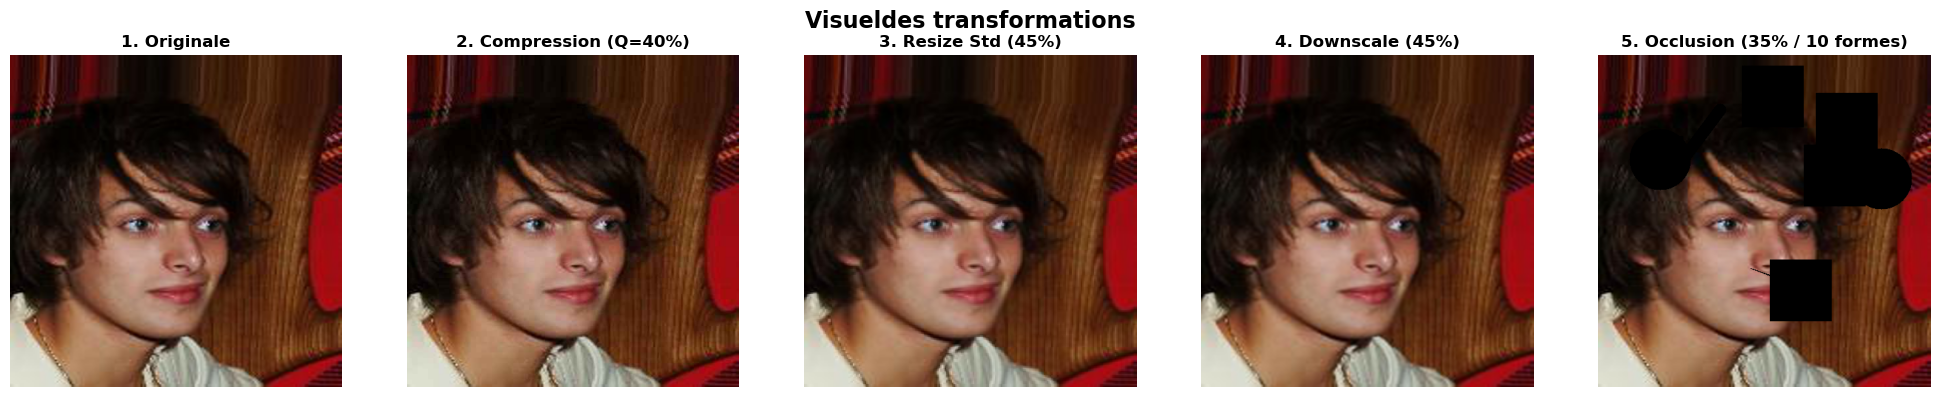

In [10]:
import matplotlib.pyplot as plt

#  PARAMÈTRES 
p_compression = 40 
p_resize      = 45   
p_occ_surface = 35   
p_occ_blocs   = 10     


cat_test = list(images_categories.keys())[0]
img_test = images_categories[cat_test][0]


img_comp = apply_compression(img_test, quality=p_compression) 
img_res_std = apply_resize_standard(img_test, scale_percent=p_resize) 
img_res_down = apply_resize_downscale(img_test, scale_percent=p_resize) 
img_occ = apply_occlusion(img_test, area_percent=p_occ_surface, num_blocks=p_occ_blocs)


fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Visueldes transformations", fontsize=16, fontweight='bold')

titres = [
    "1. Originale", 
    f"2. Compression (Q={p_compression}%)", 
    f"3. Resize Std ({p_resize}%)", 
    f"4. Downscale ({p_resize}%)", 
    f"5. Occlusion ({p_occ_surface}% / {p_occ_blocs} formes)"
]

images_a_afficher = [img_test, img_comp, img_res_std, img_res_down, img_occ]

for ax, img, titre in zip(axes, images_a_afficher, titres):
    ax.imshow(img)
    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# illusion d'optique avec matplotlib
# Vérification des dimensions et du poids 
import io

def obtenir_poids_ko(img_pil):
    """Simule une sauvegarde sur disque pour obtenir le vrai poids du fichier en Ko."""
    buffer = io.BytesIO()
    # On simule un enregistrement en JPEG standard pour peser le fichier
    img_pil.save(buffer, format="JPEG") 
    taille_octets = len(buffer.getvalue())
    return round(taille_octets / 1024, 2) # Conversion en Ko avec 2 décimale

print("--- PREUVE MATHÉMATIQUE DES DIMENSIONS ET DU POIDS ---")

print(f"1. Originale       : Dimensions {np.array(img_test).shape} | Poids : {obtenir_poids_ko(img_test)} Ko")
print(f"2. Compression     : Dimensions {np.array(img_comp).shape} | Poids : {obtenir_poids_ko(img_comp)} Ko")
print(f"3. Resize Standard : Dimensions {np.array(img_res_std).shape} | Poids : {obtenir_poids_ko(img_res_std)} Ko")
print(f"4. Downscale       : Dimensions {np.array(img_res_down).shape} | Poids : {obtenir_poids_ko(img_res_down)} Ko")
print(f"5. Occlusion       : Dimensions {np.array(img_occ).shape} | Poids : {obtenir_poids_ko(img_occ)} Ko")

--- PREUVE MATHÉMATIQUE DES DIMENSIONS ET DU POIDS ---
1. Originale       : Dimensions (500, 500, 3) | Poids : 23.52 Ko
2. Compression     : Dimensions (500, 500, 3) | Poids : 19.21 Ko
3. Resize Standard : Dimensions (225, 225, 3) | Poids : 7.85 Ko
4. Downscale       : Dimensions (500, 500, 3) | Poids : 21.8 Ko
5. Occlusion       : Dimensions (500, 500, 3) | Poids : 22.38 Ko


## **INITIALISATION DES ALGORITHMES**

### Paramètres des algorithmes de hachage

Voici les paramètres modifiables pour chaque algorithme de la bibliothèque `imagehash` et leur impact physique sur l'analyse :

#### 1. aHash (Average Hash) & dHash (Difference Hash)
* **`hash_size`** (Défaut : `8`)
  * *Valeurs possibles :* Entier positif (ex : `8`, `12`, `16`, `32`).
  * *Impact :* Définit la longueur de l'empreinte finale (ex : `8` crée un hash de 8x8 = 64 bits). 
  * *Logique :* Plus le chiffre est grand, plus l'empreinte est précise. Cependant, une empreinte trop grande deviendra intolérante et considérera deux images identiques comme différentes à la moindre petite modification.

#### 2. pHash (Perceptual Hash)
* **`hash_size`** (Défaut : `8`)
  * *Valeurs possibles :* Entier positif.
* **`highfreq_factor`** (Défaut : `4`)
  * *Valeurs possibles :* Entier positif (ex : `2`, `4`, `8`).
  * *Impact :* Définit la taille de la matrice de travail initiale. Avec `hash_size=8` et un facteur de `4`, l'image de base est calculée sur du 32x32 pixels, avant d'en extraire le cœur de 8x8.
  * *Logique :* Un facteur plus élevé donne un calcul théorique plus riche avant réduction, mais ralentit l'exécution.

#### 3. wHash (Wavelet Hash)
* **`hash_size`** (Défaut : `8`)
  * *Valeurs possibles :* Doit obligatoirement être une **puissance de 2** (ex : `8`, `16`, `32`, `64`).
* **`mode`** (Défaut : `'haar'`)
  * *Valeurs possibles :* Noms de formules mathématiques (`'haar'`, `'db4'`, `'sym5'`...).
  * *Impact :* Change la forme de l'ondelette (l'outil de découpage des fréquences). `'haar'` est la méthode la plus équilibrée et standard en traitement d'image.

#### 4. colorHash (Histogramme de couleurs)
* **`binbits`** (Défaut : `3`)
  * *Valeurs possibles :* Petit entier (ex : `2`, `3`, `4`).
  * *Impact :* Définit le niveau d'exigence sur les nuances de couleurs en créant $2^{binbits}$ "tiroirs". 
  * *Logique :* La valeur `3` crée 8 tiroirs par couleur. Si on passe à `4` (16 tiroirs), l'algorithme devient très pointilleux et différenciera un "rouge vif" d'un "rouge bordeaux". Si on descend à `2`, il regroupera presque tous les rouges dans le même tiroir.

In [12]:
import imagehash

# Ce sont les paramètres par défaut 
HASHERS = {
    "aHash": lambda im: imagehash.average_hash(im, hash_size=8),
    
    "pHash": lambda im: imagehash.phash(im, hash_size=8, highfreq_factor=4),
    
    "dHash": lambda im: imagehash.dhash(im, hash_size=8),
    
    "wHash": lambda im: imagehash.whash(im, hash_size=8, image_scale=None, mode='haar'),
    
    # colorhash analyse la répartition des couleurs
    "colorHash": lambda im: imagehash.colorhash(im, binbits=3) 
}

print("Algorithmes configurés pour l'évaluation !")

Algorithmes configurés pour l'évaluation !


## **3 : Évaluation exhaustive et Génération des CSV par catégorie**
On évalue les 4 algorithmes face à 4 transformations (Compression, Resize Standard, Resize Downscale, Occlusion) en balayant les intensités de 5 à 95 (pas de 5). Les distances de Hamming sont calculées et sauvegardées dans un fichier CSV dédié pour chaque catégorie 

In [13]:
import pandas as pd
import gc

niveaux_intensite = list(range(5, 100, 5))
print(f"Démarrage de l'évaluation exhaustive (Intensités : {niveaux_intensite})...")

# On parcourt chaque catégorie isolément
for categorie_nom, images_liste in images_categories.items():
    print(f"Traitement en cours pour la catégorie : {categorie_nom.upper()}...")
    resultats_categorie = []
    
    for img_idx, img in enumerate(images_liste):
        
        # 1. Test progressif de la COMPRESSION
        for val in niveaux_intensite:
            img_mod = apply_compression(img, quality=val)
            for algo_name, hasher in HASHERS.items():
                dist = float(hasher(img) - hasher(img_mod)) 
                resultats_categorie.append({
                    "Image_ID": img_idx,
                    "Transformation": "Compression",
                    "Intensite": val,
                    "Algo": algo_name,
                    "Distance": dist
                })
            del img_mod
            
        # 2. Test progressif du RESIZE STANDARD
        for val in niveaux_intensite:
            img_mod = apply_resize_standard(img, scale_percent=val)
            for algo_name, hasher in HASHERS.items():
                dist = float(hasher(img) - hasher(img_mod))
                resultats_categorie.append({
                    "Image_ID": img_idx,
                    "Transformation": "Resize_Standard",
                    "Intensite": val,
                    "Algo": algo_name,
                    "Distance": dist
                })
            del img_mod
            
        # 3. Test progressif du RESIZE DOWNSCALE
        for val in niveaux_intensite:
            img_mod = apply_resize_downscale(img, scale_percent=val)
            for algo_name, hasher in HASHERS.items():
                dist = float(hasher(img) - hasher(img_mod))
                resultats_categorie.append({
                    "Image_ID": img_idx,
                    "Transformation": "Resize_Downscale",
                    "Intensite": val,
                    "Algo": algo_name,
                    "Distance": dist
                })
            del img_mod

        # 4. Test progressif de l'OCCLUSION 
        for val in niveaux_intensite:
            img_mod = apply_occlusion(img, area_percent=val, num_blocks=10)
            for algo_name, hasher in HASHERS.items():
                dist = float(hasher(img) - hasher(img_mod))
                resultats_categorie.append({
                    "Image_ID": img_idx,
                    "Transformation": "Occlusion",
                    "Intensite": val,
                    "Algo": algo_name,
                    "Distance": dist
                })
            del img_mod
            
        # Libération de la mémoire après chaque image !)
        gc.collect()

    #  Création du DataFrame pour la catégorie courante
    df_cat = pd.DataFrame(resultats_categorie)
    
    # Sauvegarde dans un fichier CSV indépendant
    nom_fichier = f"{dossier_csv}/{categorie_nom}.csv"
    df_cat.to_csv(nom_fichier, index=False)
    
    print(f"[Succès] Fichier généré : {nom_fichier} ({len(df_cat)} tests enregistrés)")

print("\n TOUTES LES ÉVALUATIONS SONT TERMINÉES ET SAUVEGARDÉES !")

Démarrage de l'évaluation exhaustive (Intensités : [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95])...
Traitement en cours pour la catégorie : FACES...
[Succès] Fichier généré : resultats_csv_semaine2/faces.csv (19000 tests enregistrés)
Traitement en cours pour la catégorie : LANDSCAPES...
[Succès] Fichier généré : resultats_csv_semaine2/landscapes.csv (19000 tests enregistrés)
Traitement en cours pour la catégorie : LOGOS...
[Succès] Fichier généré : resultats_csv_semaine2/logos.csv (19000 tests enregistrés)
Traitement en cours pour la catégorie : CARS...
[Succès] Fichier généré : resultats_csv_semaine2/cars.csv (19000 tests enregistrés)
Traitement en cours pour la catégorie : ANIMALS...
[Succès] Fichier généré : resultats_csv_semaine2/animals.csv (19000 tests enregistrés)

 TOUTES LES ÉVALUATIONS SONT TERMINÉES ET SAUVEGARDÉES !


## **5 : Visualisation et Analyse Comparative**
Dans cette partie, on fusionne les résultats des 5 catégories et convertit les distances brutes en pourcentages de similarité.

In [15]:
#  Fusion et Étalonnage des résultats

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

print("Chargement et préparation des données...")


dossier_csv = "resultats_csv_semaine2" 
categories = ["faces", "landscapes", "logos", "cars", "animals"]
dfs = []

for cat in categories:
    chemin = f"{dossier_csv}/{cat}.csv"
    if os.path.exists(chemin):
        df_cat = pd.read_csv(chemin)
        df_cat['Categorie'] = cat
        dfs.append(df_cat)
    else:
        print(f" Attention : Le fichier {chemin} est introuvable.")

df_global = pd.concat(dfs, ignore_index=True)

# Étalonnage : Conversion des distances en Pourcentage de Similarité

def calculer_similarite(row):
    algo = row['Algo']
    dist = row['Distance']
    
    # Les 4 algos structurels calculent une distance sur 64 bits (car hash_size=8 -> 8x8 = 64)
    if algo in ['aHash', 'pHash', 'dHash', 'wHash']:
        sim = 100 - (dist / 64) * 100
        
    # CORRECTION : colorHash sur binbits=3 est codé sur 42 bits (14 catégories * 3 bits)
    # La distance maximale est donc de 42.
    elif algo == 'colorHash':
        sim = 100 - (dist / 42.0) * 100 
        
    else:
        sim = 100 - (dist / 64) * 100
        
    # Sécurité : Pas de similarité négative sur le graphique
    return max(0, min(sim, 100))

df_global['Similarite_Pct'] = df_global.apply(calculer_similarite, axis=1)

# Configuration esthétique globale pour les graphiques suivants
sns.set_theme(style="whitegrid")
transformations = ['Compression', 'Resize_Standard', 'Resize_Downscale', 'Occlusion']

print(f" Données prêtes ! Le tableau df_global contient {len(df_global)} lignes.")

Chargement et préparation des données...
 Données prêtes ! Le tableau df_global contient 95000 lignes.


## **5.1 : Comparaison de la Robustesse des Algorithmes**
Ce bloc génère une figure composée de 4 graphiques (un par type d'attaque). Il trace l'évolution du pourcentage de similarité de chaque algorithme en fonction de l'intensité de la modification.

Génération des courbes de comparaison des algorithmes...


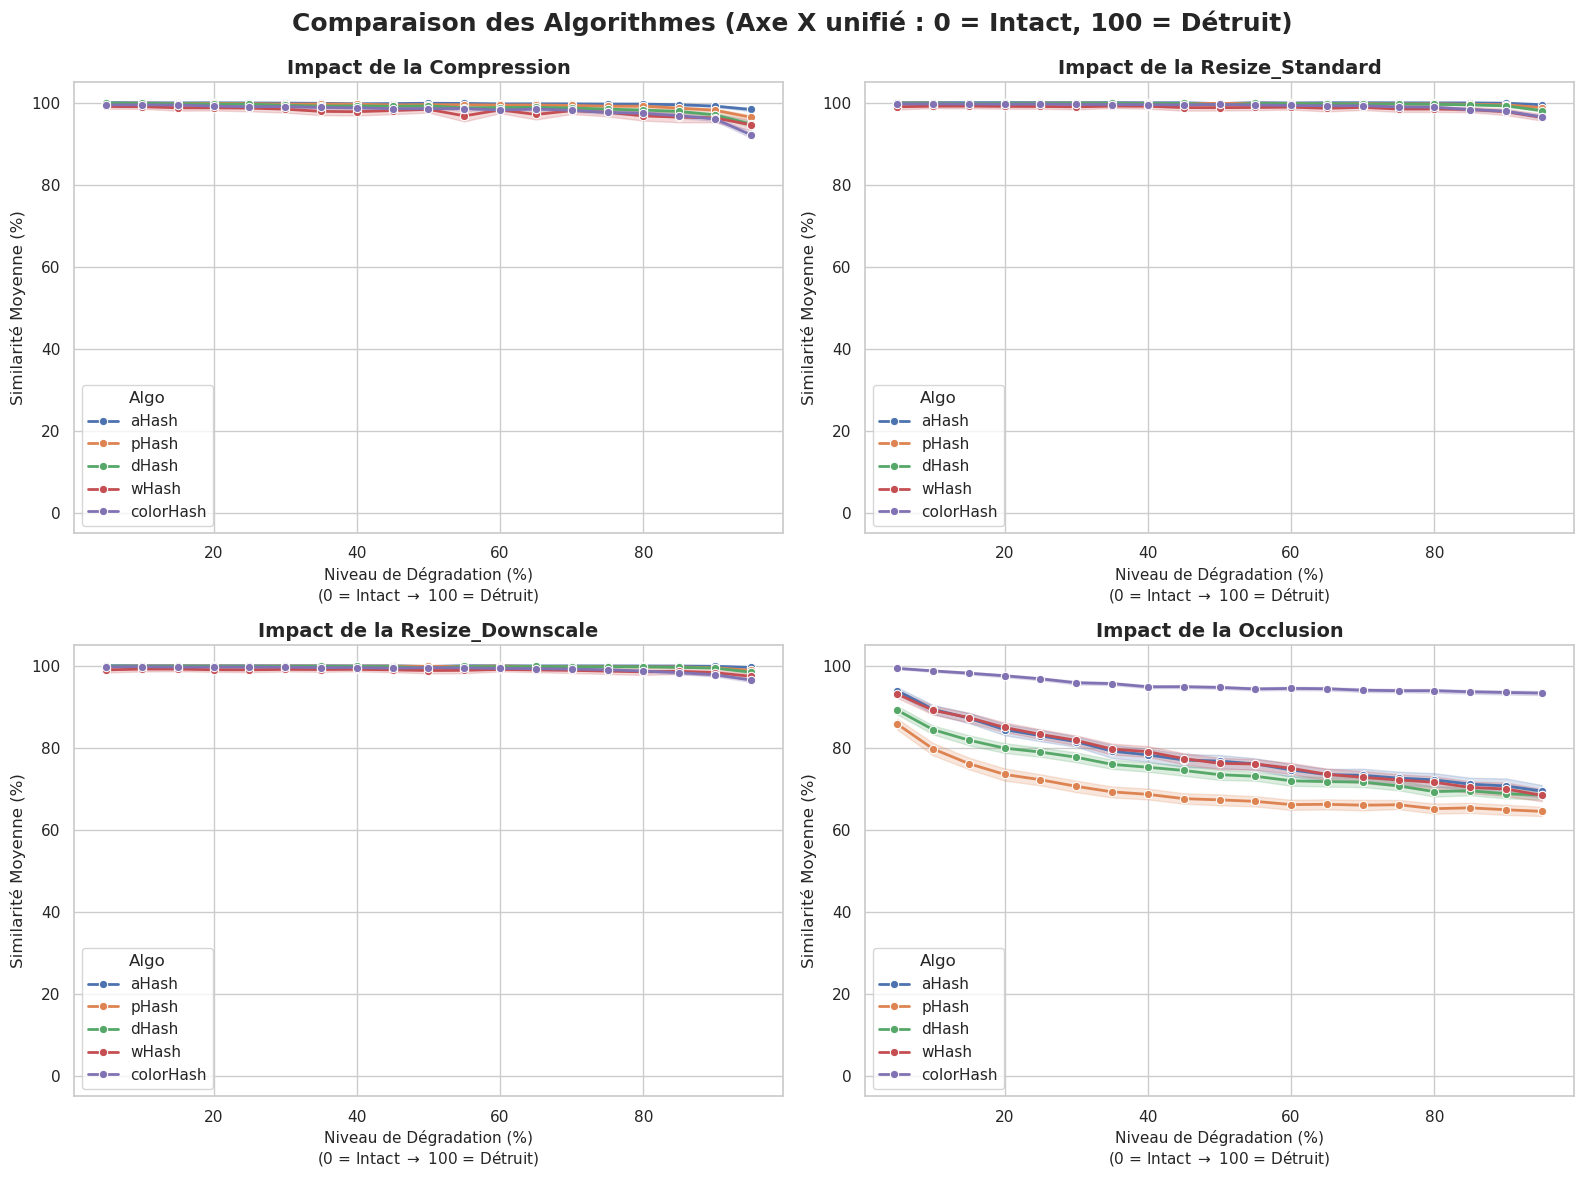

In [16]:
#Comparaison des performances algorithmiques

import matplotlib.pyplot as plt
import seaborn as sns

print("Génération des courbes de comparaison des algorithmes...")

# 1. Étalonnage de l'Axe X (Pour que 0% = Intact et 100% = Détruit pour tous les graphiques)
def calculer_degradation(row):
    # Pour l'occlusion, l'intensité (surface cachée) EST la dégradation
    if row['Transformation'] == 'Occlusion':
        return row['Intensite'] 
    # Pour la compression et les resizes, 100% d'intensité = qualité max (donc 0% de dégradation)
    else:
        return 100 - row['Intensite'] 

df_global['Niveau_Degradation'] = df_global.apply(calculer_degradation, axis=1)

# 2. Création de la figure (Grille 2x2)
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle("Comparaison des Algorithmes (Axe X unifié : 0 = Intact, 100 = Détruit)", fontsize=18, fontweight='bold')
axes1 = axes1.flatten() # Transforme la matrice 2x2 en une liste simple de 4 cases

transformations = ['Compression', 'Resize_Standard', 'Resize_Downscale', 'Occlusion']

for i, transfo in enumerate(transformations):
    df_t = df_global[df_global['Transformation'] == transfo]
    
    # Trace les lignes (une couleur par algorithme)
    sns.lineplot(data=df_t, x='Niveau_Degradation', y='Similarite_Pct', hue='Algo', marker='o', linewidth=2, ax=axes1[i])
    
    # Esthétique de chaque sous-graphique
    axes1[i].set_title(f"Impact de la {transfo}", fontsize=14, fontweight='bold')
    axes1[i].set_ylabel("Similarité Moyenne (%)", fontsize=12)
    axes1[i].set_ylim(-5, 105) # Force l'axe Y à aller de 0 à 100%
    
    # Label explicatif pour l'axe X
    axes1[i].set_xlabel("Niveau de Dégradation (%)\n(0 = Intact $\\rightarrow$ 100 = Détruit)", fontsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Laisse de la place pour le grand titre global
plt.show()

## **5.3 : Comparaison des Catégories d'Images**
Ce bloc génère une figure comparant la vulnérabilité des différents types d'images (visages, logos, paysages, voitures, animaux) face aux mêmes attaques. L'objectif est d'observer si la structure géométrique ou la texture d'une image influence la résistance de son empreinte de hachage.

Génération des courbes de comparaison des catégories d'images...


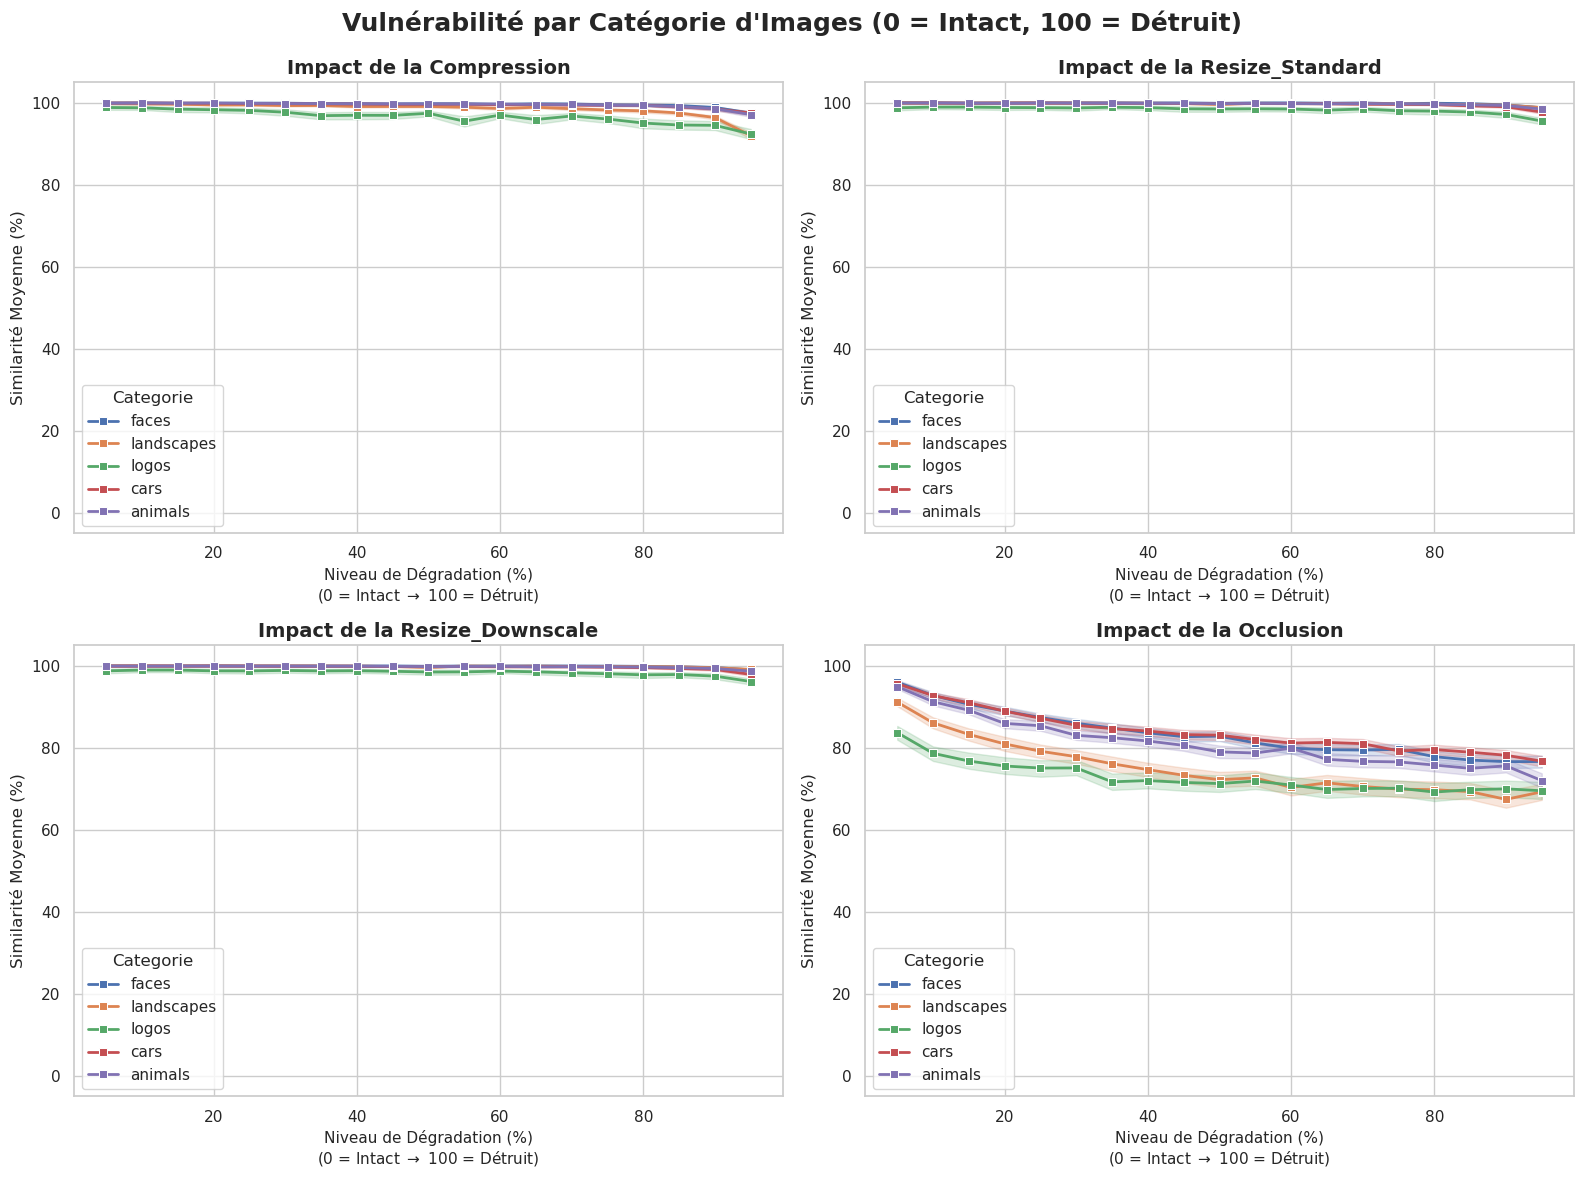

In [17]:
#  Vulnérabilité selon le type de contenu visuel

import matplotlib.pyplot as plt
import seaborn as sns

print("Génération des courbes de comparaison des catégories d'images...")

# Création de la figure (Grille 2x2)
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Vulnérabilité par Catégorie d'Images (0 = Intact, 100 = Détruit)", fontsize=18, fontweight='bold')
axes2 = axes2.flatten()

transformations = ['Compression', 'Resize_Standard', 'Resize_Downscale', 'Occlusion']

for i, transfo in enumerate(transformations):
    df_t = df_global[df_global['Transformation'] == transfo]
    
    # Trace les lignes (une couleur par catégorie d'image)
    sns.lineplot(data=df_t, x='Niveau_Degradation', y='Similarite_Pct', hue='Categorie', marker='s', linewidth=2, ax=axes2[i])
    
    # Esthétique
    axes2[i].set_title(f"Impact de la {transfo}", fontsize=14, fontweight='bold')
    axes2[i].set_ylabel("Similarité Moyenne (%)", fontsize=12)
    axes2[i].set_ylim(-5, 105)
    
    # Label explicatif unifié
    axes2[i].set_xlabel("Niveau de Dégradation (%)\n(0 = Intact $\\rightarrow$ 100 = Détruit)", fontsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

###  Analyse microscopique des performances

Après avoir observé les tendances globales, ce bloc effectue une analyse granulaire : **une figure complète pour chaque catégorie d'image**.

**Objectif de cette étape :**
* **Casser la moyenne globale** pour observer le comportement réel des algorithmes sur des données spécifiques.
* **Identifier l'algorithme optimal** selon le type de contenu 


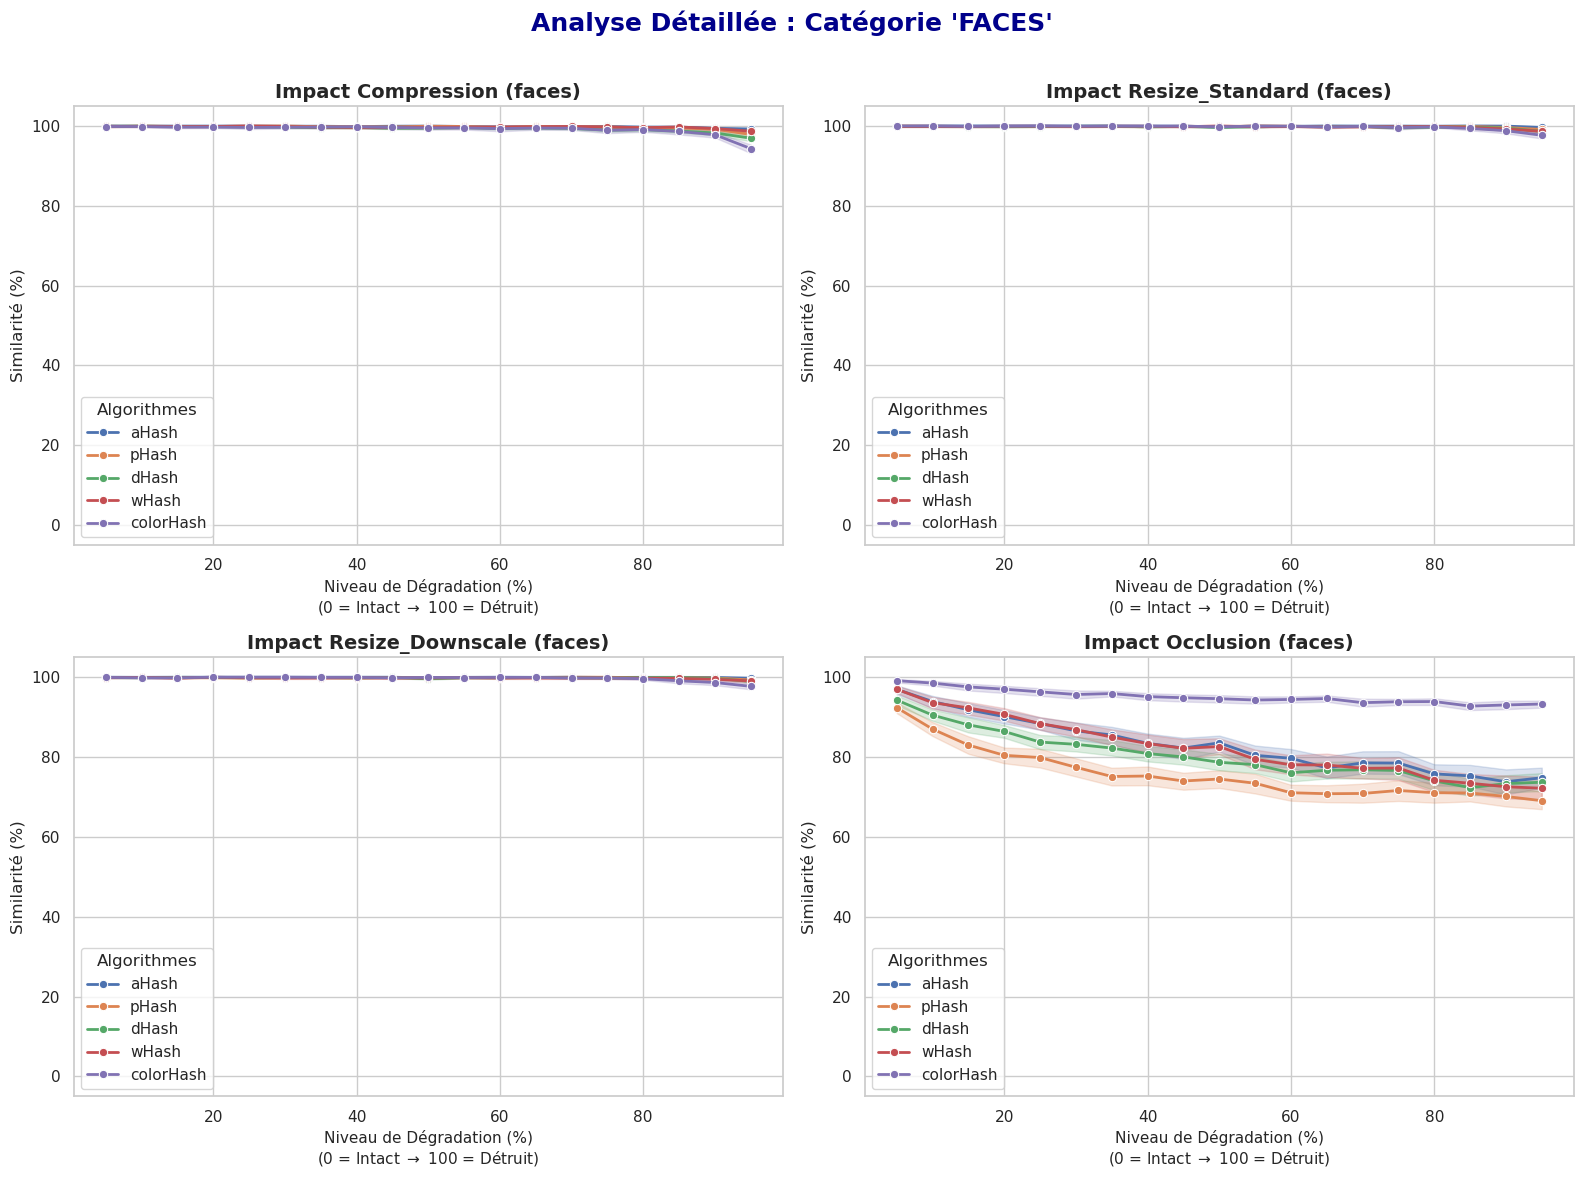

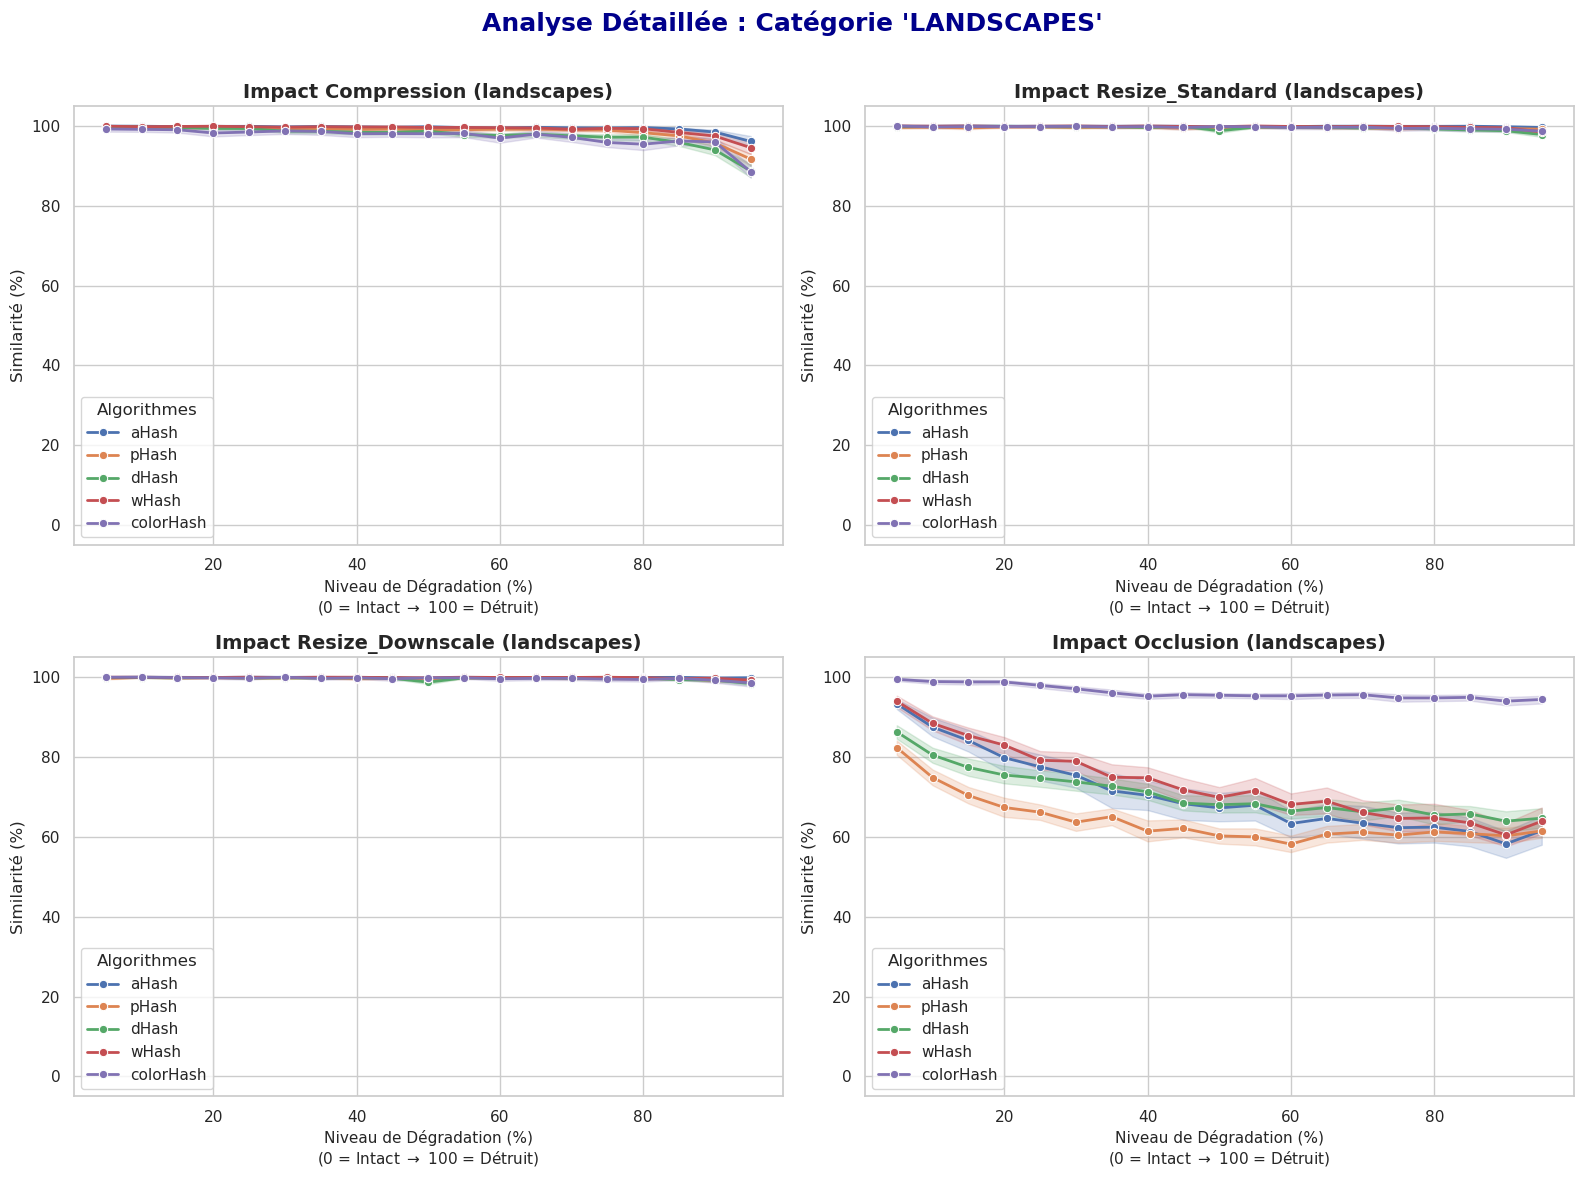

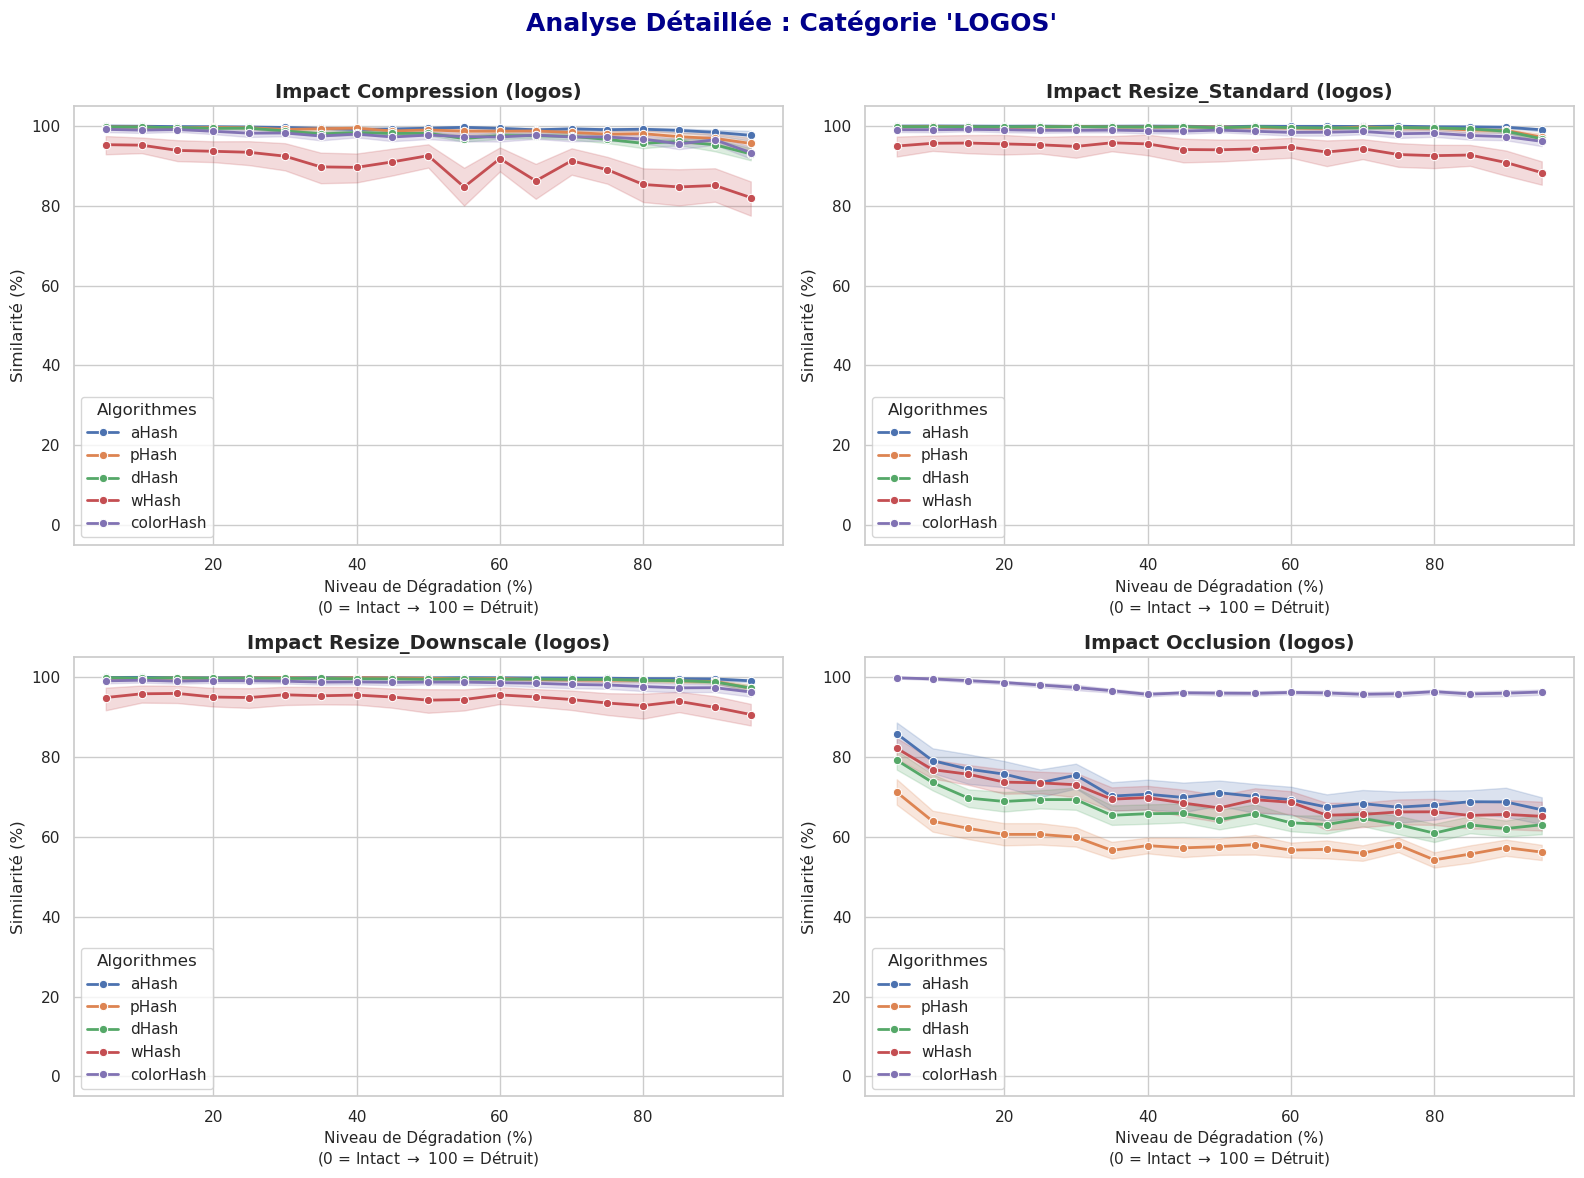

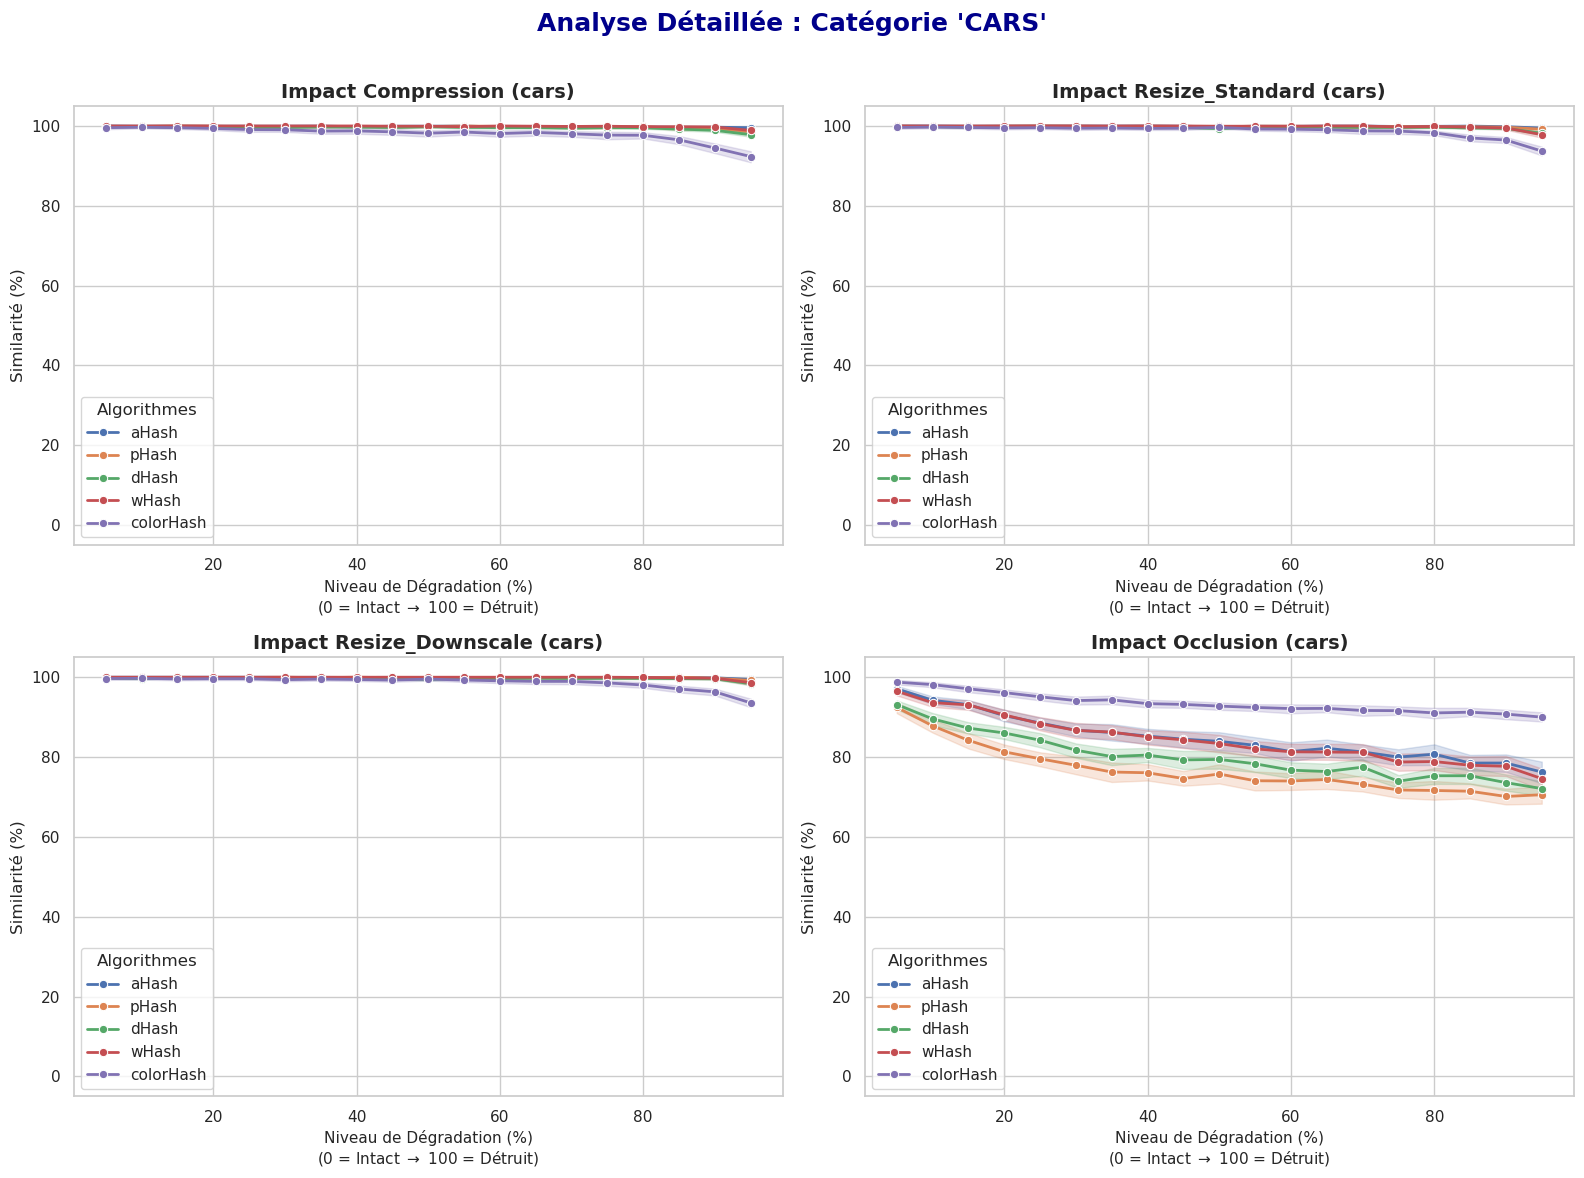

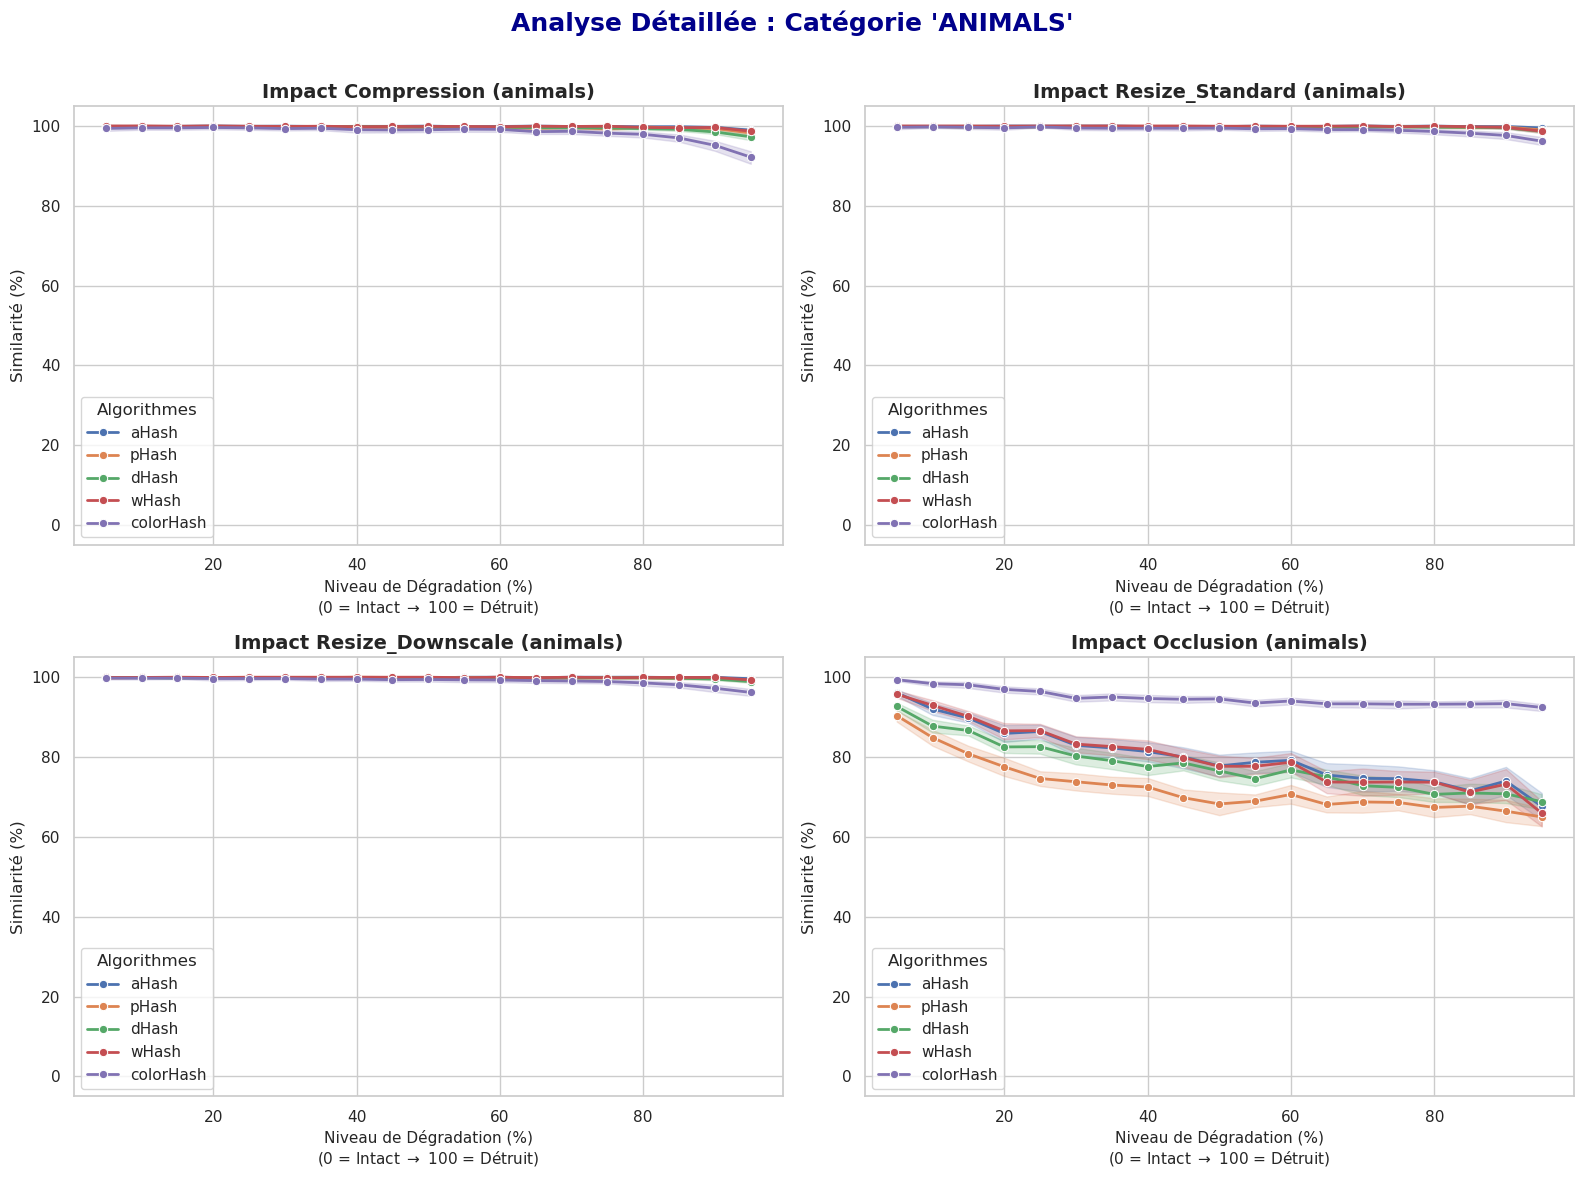

In [18]:
# Détail des algorithmes pour chaque catégorie

import matplotlib.pyplot as plt
import seaborn as sns


categories_uniques = df_global['Categorie'].unique()
transformations = ['Compression', 'Resize_Standard', 'Resize_Downscale', 'Occlusion']

for cat in categories_uniques:
    
    #  On isole uniquement les lignes qui concernent cette catégorie
    df_cat_only = df_global[df_global['Categorie'] == cat]
    
    # Figure pour cette catégorie 
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Analyse Détaillée : Catégorie '{cat.upper()}'\n", 
                 fontsize=18, fontweight='bold', color='darkblue')
    axes = axes.flatten()
    
    for i, transfo in enumerate(transformations):
        # On filtre par transformation 
        df_t = df_cat_only[df_cat_only['Transformation'] == transfo]
        
        # On trace les lignes des 5 algorithmes
        sns.lineplot(data=df_t, x='Niveau_Degradation', y='Similarite_Pct', hue='Algo', marker='o', linewidth=2, ax=axes[i])
        
        # Esthétique
        axes[i].set_title(f"Impact {transfo} ({cat})", fontsize=14, fontweight='bold')
        axes[i].set_ylabel("Similarité (%)", fontsize=12)
        axes[i].set_ylim(-5, 105)
        axes[i].set_xlabel("Niveau de Dégradation (%)\n(0 = Intact $\\rightarrow$ 100 = Détruit)", fontsize=11)
        
        # On place la légende
        axes[i].legend(loc='lower left', title='Algorithmes')

    plt.tight_layout()
    plt.subplots_adjust(top=0.90) 
    plt.show() 